<a href="https://colab.research.google.com/github/Nishkarsh5108/agri-Waste-biomass-valuation-engine/blob/main/yolov8_weed_detection_core.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import json

# 1. Type your Kaggle username and paste the key
kaggle_creds = {
    "username": "manyaa23",
    "key": "KGAT_28c2908593ab41ff29987fd429625993"
}

# 2. Create the hidden Kaggle folder
os.makedirs('/root/.kaggle/', exist_ok=True)

# 3. Write the file directly into Colab
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

# 4. Secure the file permissions
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Boom! Kaggle key is successfully configured!")

Boom! Kaggle key is successfully configured!


In [ ]:
!unzip -q weedcrop-image-dataset.zip -d dataset/

replace dataset/WeedCrop.v1i.yolov5pytorch/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
!kaggle datasets download -d vinayakshanawad/weedcrop-image-dataset
!unzip -q weedcrop-image-dataset.zip -d dataset/

Dataset URL: https://www.kaggle.com/datasets/vinayakshanawad/weedcrop-image-dataset
License(s): CC0-1.0
100% 251M/251M [00:15<00:00, 16.8MB/s]



In [ ]:
# 1. Install the library
!pip install ultralytics

# 2. Train the model (Notice we added device=0 to force the GPU!)
!yolo task=detect mode=train model=yolov8n.pt data=/content/dataset/WeedCrop.v1i.yolov5pytorch/data.yaml epochs=15 imgsz=640 device=0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 71.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/WeedCrop.v1i.yolov5pytorch/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=N

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


image 1/1 /content/dataset/WeedCrop.v1i.yolov5pytorch/valid/images/34102_jpg.rf.1ec0cbf4db4982f7410264c1463ef508.jpg: 384x640 13 weeds, 13.6ms
Speed: 4.2ms preprocess, 13.6ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict-2


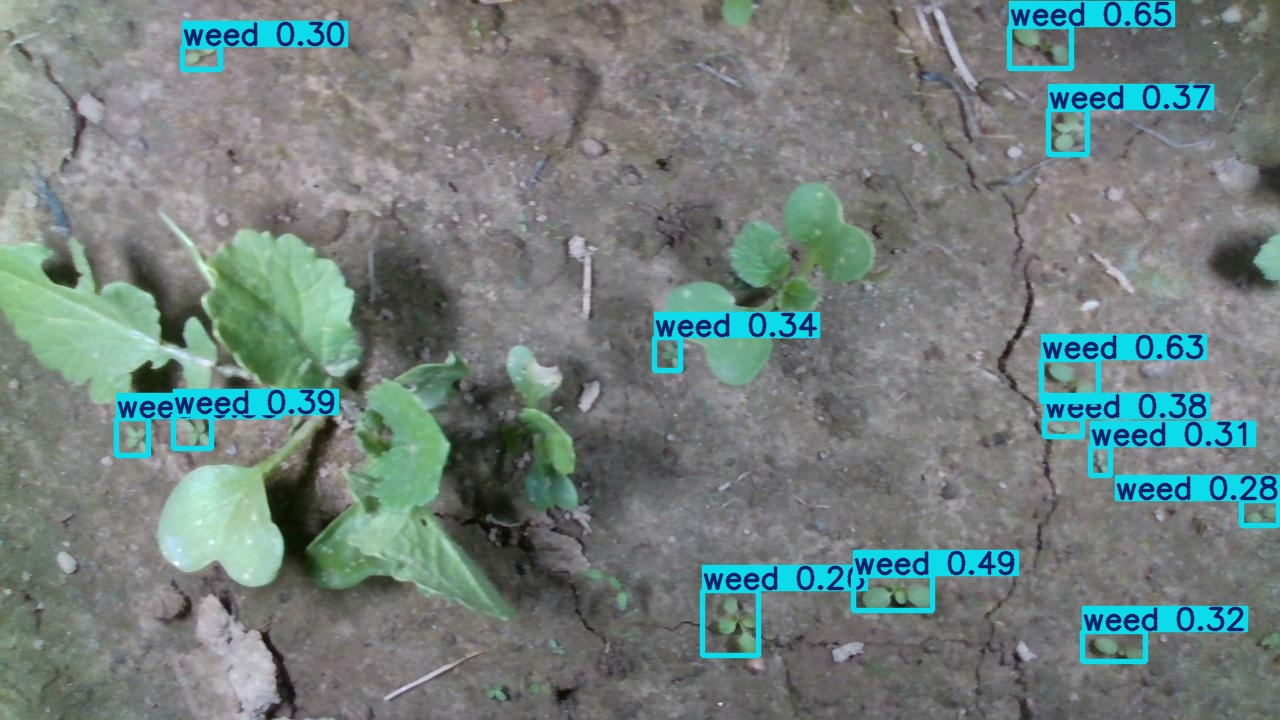

In [ ]:
from ultralytics import YOLO
import glob
import os
from IPython.display import Image, display

# 1. Load your newly trained brain
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Grab a random test image from the validation set
test_image = glob.glob('/content/dataset/WeedCrop.v1i.yolov5pytorch/valid/images/*.jpg')[0]

# 3. Run the AI prediction! (save=True tells it to draw the boxes)
results = model(test_image, save=True)

# 4. Display the final result right here in Colab
saved_path = os.path.join(results[0].save_dir, os.path.basename(test_image))
display(Image(filename=saved_path))